In [23]:
import shutil
import random
from pathlib import Path
from typing import Literal

PoisonSource = Literal["glasses", "beard"]
Split = Literal["train", "test", "both"]

def create_replaced_mix_dataset(
    yale_root: str,
    poison_rate: float,
    poison_source: PoisonSource = "glasses",
    split: Split = "train",
    seed: int = 42,
    per_class: bool = True,
    out_parent: str | None = None,
    write_mapping_csv: bool = True,
) -> str:
    """
    Creates ONE folder like:
      <out_parent>/Yale_0.1/poisoned_glasses_replaced

    For each class folder (01..15) it creates a mixed dataset where a fraction
    of images are REPLACED by their poisoned counterparts.

    Replacement is done by sorted index pairing:
      i-th original <-> i-th poison

    poison_rate meaning:
      0.0 => all original
      1.0 => all poisoned (as many as matchable by index; requires poison count >= original count)
    """

    if not (0.0 <= poison_rate <= 1.0):
        raise ValueError("poison_rate must be between 0.0 and 1.0")

    random.seed(seed)
    in_root = Path(yale_root)
    if not in_root.exists():
        raise FileNotFoundError(f"yale_root not found: {in_root}")

    rate_str = f"{poison_rate:.3f}".rstrip("0").rstrip(".")
    out_parent_path = Path(out_parent) if out_parent else in_root.parent
    out_root = out_parent_path / f"Yale_{rate_str}" / f"poisoned_{poison_source}_replaced"

    if out_root.exists():
        raise FileExistsError(f"Output folder already exists: {out_root}")
    out_root.mkdir(parents=True, exist_ok=False)

    def list_pngs(folder: Path) -> list[Path]:
        if not folder.exists():
            return []
        return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".png"])

    mapping_rows = []  # split,class,idx,original_file,poison_file,replaced(True/False)

    def build_one_split(split_suffix: str, out_split_name: str) -> int:
        original_base = in_root / f"original_{split_suffix}"
        poison_base = in_root / f"{poison_source}_{split_suffix}"

        if not original_base.exists():
            raise FileNotFoundError(f"Missing folder: {original_base}")
        if not poison_base.exists():
            raise FileNotFoundError(f"Missing folder: {poison_base}")

        class_dirs = sorted([p for p in original_base.iterdir() if p.is_dir()], key=lambda p: p.name)
        if not class_dirs:
            raise RuntimeError(f"No class subfolders found in {original_base}")

        out_split_dir = out_root / out_split_name
        out_split_dir.mkdir(parents=True, exist_ok=True)

        total_replaced = 0

        for cls_dir in class_dirs:
            poison_cls = poison_base / cls_dir.name
            if not poison_cls.exists():
                continue

            originals = list_pngs(cls_dir)
            poisons = list_pngs(poison_cls)
            if not originals:
                continue
            if not poisons:
                continue

            # For replacement we need poison at least as many as originals to achieve 100%
            if poison_rate == 1.0 and len(poisons) < len(originals):
                raise RuntimeError(
                    f"[{out_split_name}/{cls_dir.name}] poison images ({len(poisons)}) < originals ({len(originals)}). "
                    "Cannot make 100% poisoned with index pairing."
                )

            out_cls = out_split_dir / cls_dir.name
            out_cls.mkdir(parents=True, exist_ok=True)

            # First copy ALL originals (keeps exact count and filenames)
            for o in originals:
                shutil.copy2(o, out_cls / o.name)

            n = min(len(originals), len(poisons))  # max safely replaceable by index
            if per_class:
                k = int(round(poison_rate * len(originals)))
                # We can only replace up to n
                k = min(k, n)
                # If poison_rate=1, k becomes len(originals) and requires n=len(originals)
                chosen_idx = random.sample(range(len(originals)), k) if k else []
            else:
                k = int(round(poison_rate * len(originals)))
                k = min(k, n)
                chosen_idx = random.sample(range(len(originals)), k) if k else []

            # Replace selected indices with poison versions, keeping original filenames
            # idx refers to originals list index; poison taken from same idx.
            for idx in sorted(chosen_idx):
                if idx >= n:
                    # cannot replace beyond available poison pairs
                    continue
                orig = originals[idx]
                poi = poisons[idx]
                dst = out_cls / orig.name
                shutil.copy2(poi, dst)  # overwrite original with poison
                total_replaced += 1
                mapping_rows.append((out_split_name, cls_dir.name, idx, orig.name, poi.name, True))

        return total_replaced

    replaced_total = 0
    if split in ("train", "both"):
        replaced_total += build_one_split("extended", "train")
    if split in ("test", "both"):
        replaced_total += build_one_split("test_extended", "test")

    if write_mapping_csv:
        csv_path = out_root / "mapping.csv"
        with open(csv_path, "w", encoding="utf-8") as f:
            f.write("split,class,idx,original_filename,poison_filename,replaced\n")
            for row in mapping_rows:
                f.write(",".join(map(str, row)) + "\n")

    print(f"DONE. Replaced images: {replaced_total}")
    print("Output folder:", out_root)
    if write_mapping_csv:
        print("Mapping file :", out_root / "mapping.csv")

    return str(out_root)

## Creating new poisoned Dataset 

In [51]:
from pathlib import Path


root = Path(r"C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale")


out_path = create_replaced_mix_dataset(
    yale_root=str(root),
    poison_rate=.5,
    poison_source="beard",
    split="train",
    seed=1,
    per_class=True
)
print("Created:", out_path)

DONE. Replaced images: 475
Output folder: C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale_0.5\poisoned_beard_replaced
Mapping file : C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale_0.5\poisoned_beard_replaced\mapping.csv
Created: C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale_0.5\poisoned_beard_replaced


## Train AutoEncoder

Import AutoEncoderDEfense

In [25]:
#import AutoendoderDefense
import sys
from pathlib import Path

# Notebook liegt in .../Ex3/
PROJECT_ROOT = Path.cwd().resolve().parents[0]   # eine Ebene hoch = Repo Root
# Falls du das Notebook aus einem anderen Working Directory startest:
# PROJECT_ROOT = Path(__file__).resolve().parents[1]  # klappt in .py, nicht in ipynb

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("BackdoorBox exists:", (PROJECT_ROOT / "BackdoorBox").exists())




from BackdoorBox.core.defenses import AutoEncoderDefense

Project root: C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning
BackdoorBox exists: True


Load Original Data

In [26]:
from pathlib import Path
from torchvision import datasets, transforms

data_root = Path(r"C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale")

train_dir = data_root / "original_extended"
test_dir  = data_root / "original_test_extended"  # falls vorhanden

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(str(train_dir), transform=transform)
test_dataset  = datasets.ImageFolder(str(test_dir),  transform=transform)

print("Train:", len(train_dataset), "Test:", len(test_dataset))
print("Classes:", len(train_dataset.classes))

Train: 1350 Test: 300
Classes: 15


Train AutoEncoder

In [27]:
from torch.utils.data import random_split

n = len(train_dataset)
n_test = int(0.1 * n)
n_train = n - n_test
train_dataset, test_dataset = random_split(train_dataset, [n_train, n_test])
print("Train:", len(train_dataset), "Test:", len(test_dataset))

Train: 1215 Test: 135


In [80]:
import torch
import torch.nn as nn

class DenoisingWrapper(nn.Module):
    def __init__(self, model, noise_factor=0.2):
        super(DenoisingWrapper, self).__init__()
        self.model = model
        self.noise_factor = noise_factor

    def forward(self, x):
        if self.training:
            # Rauschen erzeugen
            noise = torch.randn_like(x) * self.noise_factor
            # Rauschen auf das Bild addieren
            x_noisy = x + noise
            # Werte wieder auf den gültigen Bereich 0-1 beschränken
            x_noisy = torch.clamp(x_noisy, 0., 1.)
            return self.model(x_noisy)
        else:
            # Im Testmodus kein Rauschen hinzufügen!
            return self.model(x)


class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: 128 -> 64 -> 32 -> 16
        self.enc = nn.Sequential(
            # 128 -> 64
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=1, padding=1), nn.ReLU(),   # refine @64

            # 64 -> 32
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1, padding=1), nn.ReLU(),   # refine @32

            # 32 -> 16
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, stride=1, padding=1), nn.ReLU(), # refine @16
        )

        # Decoder: 16 -> 32 -> 64 -> 128
        self.dec = nn.Sequential(
            # 16 -> 32
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1, padding=1), nn.ReLU(),   # refine @32

            # 32 -> 64
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=1, padding=1), nn.ReLU(),   # refine @64

            # 64 -> 128
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Sigmoid()  # wichtig für BCELoss in BackdoorBox
        )

    def forward(self, x):
        return self.dec(self.enc(x))
    
basis_ae = ConvAE()    

autoencoder = DenoisingWrapper(basis_ae, noise_factor=0.2)

In [81]:
from BackdoorBox.core.defenses import AutoEncoderDefense

aed = AutoEncoderDefense(autoencoder=autoencoder, pretrain=None, seed=1, deterministic=False)

In [82]:
schedule = {
    "device": "GPU",              # "CPU" oder weglassen für CPU
    "GPU_num": 1,
    # "CUDA_VISIBLE_DEVICES": "0",

    "batch_size": 16,
    # Windows/Jupyter: num_workers>0 crasht häufig wegen multiprocessing/spawn
    "num_workers": 0,

    "lr": 1e-3,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0.0,
    "amsgrad": False,

    "epochs": 40,
    "schedule": [25, 35],         # bei epoch 25 und 35 lr *= gamma
    "gamma": 0.1,

    "log_iteration_interval": 50,
    "test_epoch_interval": 1,
    "save_epoch_interval": 5,

    "save_dir": str(data_root / "experiments"),
    "experiment_name": "yale_autoencoder_clean"
}

In [83]:
aed.train_autoencoder(train_dataset, test_dataset, schedule)

This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 1215
Total test samples: 135
Batch size: 16
iteration every epoch: 75
Initial learning rate: 0.001

[2026-02-03_21:51:29] Epoch:1/40, iteration:50/75, lr: 0.001, loss: 0.3985676169395447, time: 1.386305809020996

==========Test result on test dataset==========
[2026-02-03_21:51:29] loss: 0.40156009793281555, time: 0.8681032657623291

[2026-02-03_21:51:30] Epoch:2/40, iteration:24/75, lr: 0.001, loss: 0.35126614570617676, time: 1.4501354694366455

[2026-02-03_21:51:31] Epoch:2/40, iteration:74/75, lr: 0.001, loss: 0.40488091111183167, time: 1.2129855155944824

==========Test result on test dataset==========
[2026-02-03_21:51:31] loss: 0.3749198913574219, time: 0.23614931106567383

[2026-02-03_21:51:33] Epoch:3/40, iteration:48/75, lr: 0.001, loss: 0.3601606786251068, time: 1.4140546321868896

==========Test result on test dataset==========
[2026-02-03_21:51:33] loss: 0.3887377381324768, time: 0.88347411155

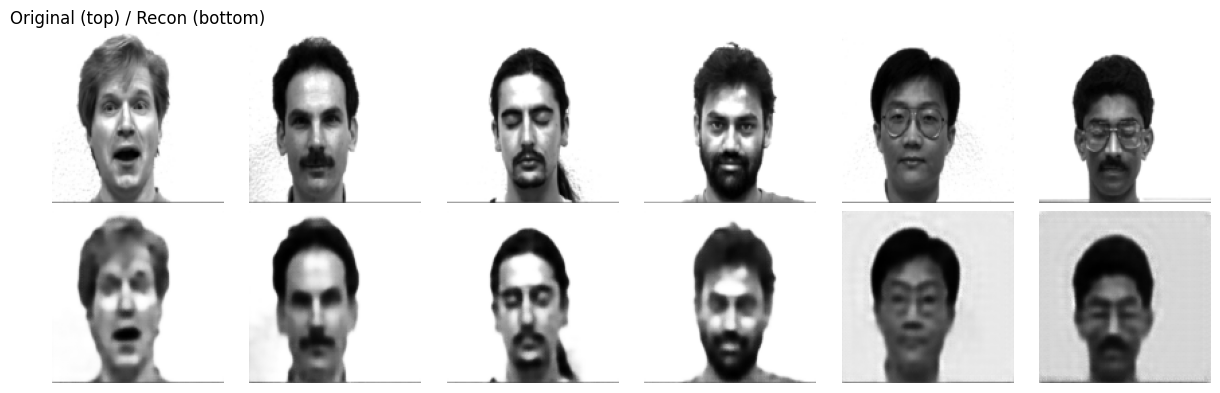

In [65]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
aed.autoencoder = aed.autoencoder.to(device)
aed.autoencoder.eval()

loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

x, _ = next(iter(loader))
x = x.to(device)

with torch.no_grad():
    x_rec = aed.preprocess(x)

# plot first 6
x_cpu = x.detach().cpu()
r_cpu = x_rec.detach().cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(x_cpu[i].squeeze(0), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(r_cpu[i].squeeze(0), cmap="gray")
    axes[1, i].axis("off")
axes[0,0].set_title("Original (top) / Recon (bottom)")
plt.tight_layout()
plt.show()

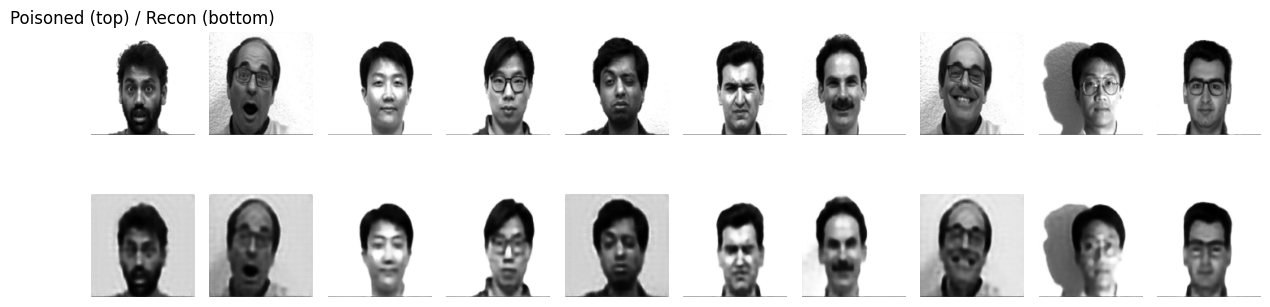

In [74]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch, matplotlib.pyplot as plt
from pathlib import Path

data_root = Path(r"C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale_0.5\poisoned_glasses_replaced")
poison_dir = data_root / "train"  # oder beard_extended

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

poison_ds = datasets.ImageFolder(str(poison_dir), transform=transform)
poison_loader = DataLoader(poison_ds, batch_size=10, shuffle=True)

x, _ = next(iter(poison_loader))
x = x.to(device)

with torch.no_grad():
    xr = aed.preprocess(x)

x_cpu = x.detach().cpu()
r_cpu = xr.detach().cpu()

fig, axes = plt.subplots(2, 10, figsize=(12, 4))
for i in range(10):
    axes[0, i].imshow(x_cpu[i].squeeze(0), cmap="gray"); axes[0,i].axis("off")
    axes[1, i].imshow(r_cpu[i].squeeze(0), cmap="gray"); axes[1,i].axis("off")
axes[0,0].set_title("Poisoned (top) / Recon (bottom)")
plt.tight_layout(); plt.show()

In [79]:
from torch.utils.data import DataLoader
import torch.nn.functional as F

def calculate_average_loss(model, dataset, device="cuda", batch_size=64):
    model.eval()
    model.to(device)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs = model(images)
            # MSE Loss berechnen
            loss = F.mse_loss(outputs, images)
            total_loss += loss.item()
            num_batches += 1
            
    avg_loss = total_loss / num_batches
    print(f"Durchschnittlicher MSE Loss auf dem Testset: {avg_loss:.6f}")
    return avg_loss

# Berechnung starten
calculate_average_loss(autoencoder, test_dataset)

Durchschnittlicher MSE Loss auf dem Testset: 0.000841


0.0008407489901098112